## Cell 1 - Install & Import

In [19]:
!pip install neat-python -q

In [20]:
import neat
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import deque
from IPython.display import display, update_display
import time
import pickle
import gzip
import heapq
from pathlib import Path
import math

## Cell 2 - Constants & Config

In [21]:
# ── Map size ──────────────────────────────────────────────
MIN_WIDTH,  MAX_WIDTH  = 14, 14
MIN_HEIGHT, MAX_HEIGHT = 14, 14

# ── Training ──────────────────────────────────────────────
MAPS_PER_GENOME = 6       # paper dùng N=6 levels / genome (Table 9 Maze)
MAX_GEN         = 200     # paper Maze = 200 generations
POP_SIZE        = 50
LAMBDA_ARCHIVE  = 1       # paper: thêm ngẫu nhiên λ individuals vào archive mỗi gen
MODEL_PATH      = "neat_winner.pkl"
MAP_TXT_DIR     = "saved_maps_txt"

# ── Tile types (Maze domain: chỉ WALL + FLOOR; PLAYER/ENEMY là post-processing) ──
# Paper: network chỉ predict WALL/FLOOR. Spawn entities sau khi generate.
WALL   = 0
FLOOR  = 1
PLAYER = 2
ENEMY  = 3
# Network chỉ output 2 loại tile (WALL / FLOOR) — đúng paper Maze domain
N_NETWORK_TILES = 2   # output của NEAT network
N_TILE_TYPES    = 4   # tổng số tile (gồm cả PLAYER, ENEMY cho visualize)

TILE_COLORS = {
    WALL:   [0.2,  0.2,  0.2],
    FLOOR:  [0.95, 0.95, 0.95],
    PLAYER: [0.2,  0.8,  0.2],
    ENEMY:  [0.9,  0.2,  0.2],
}

# ── Novelty Search (paper Table 9 Maze) ───────────────────
NOVELTY_K           = 15    # paper: 15 neighbours
NOVELTY_W_SOLVABLE  = 0.202 # paper: Solvability × 0.202
NOVELTY_W_INTRA     = 0.399 # paper: Intra-Novelty × 0.399
NOVELTY_W_INTER     = 0.399 # paper: Novelty (inter) × 0.399
ARCHIVE_MAX_SIZE    = 500

# ── Input encoding ────────────────────────────────────────
# Paper context_size=1 → 3×3 window minus center = 8 tiles
# Mỗi tile one-hot(2) (WALL/FLOOR) → 8×2 = 16 inputs
# + 4 noise/random inputs (paper: NUM_RANDOM_VARIABLES=4)
CONTEXT_SIZE  = 1            # 1 ô xung quanh (3×3 window)
CTX_TILES     = (2*CONTEXT_SIZE+1)**2 - 1   # = 8
NUM_INPUTS    = CTX_TILES * N_NETWORK_TILES + 4   # 8×2 + 4 = 20
NUM_OUTPUTS   = N_NETWORK_TILES                   # 2

print(f"Context tiles : {CTX_TILES}")
print(f"Inputs        : {NUM_INPUTS}")
print(f"Outputs       : {NUM_OUTPUTS}")
print(f"Novelty K     : {NOVELTY_K}, λ={LAMBDA_ARCHIVE}")

Context tiles : 8
Inputs        : 20
Outputs       : 2
Novelty K     : 15, λ=1


## Cell 3 - Map Generation (3×3 Context theo paper PCGNN)

In [22]:
# ─────────────────────────────────────────────────────────
# One-hot encoding cho tile WALL/FLOOR
# ─────────────────────────────────────────────────────────
def tile_to_onehot_2(val):
    if val == WALL:
        return [1.0, 0.0]
    else:
        return [0.0, 1.0]


# ─────────────────────────────────────────────────────────
# Core generator theo paper PCGNN
# ─────────────────────────────────────────────────────────
PERTURB_SIZE = 0.1565   # paper Table 9 Maze

def generate_level(net, map_h=None, map_w=None, perturb=True):
    if map_h is None:
        map_h = random.randint(MIN_HEIGHT, MAX_HEIGHT)
    if map_w is None:
        map_w = random.randint(MIN_WIDTH, MAX_WIDTH)

    padded = np.full((map_h + 2*CONTEXT_SIZE, map_w + 2*CONTEXT_SIZE), -1, dtype=int)

    for r in range(CONTEXT_SIZE, map_h + CONTEXT_SIZE):
        for c in range(CONTEXT_SIZE, map_w + CONTEXT_SIZE):
            ctx = []
            for dr in range(-CONTEXT_SIZE, CONTEXT_SIZE + 1):
                for dc in range(-CONTEXT_SIZE, CONTEXT_SIZE + 1):
                    if dr == 0 and dc == 0:
                        continue
                    v = padded[r + dr, c + dc]
                    tile = FLOOR if v < 0 else v
                    ctx.extend(tile_to_onehot_2(tile))

            noise = [random.random() for _ in range(4)]
            inputs = ctx + noise
            if perturb:
                inputs = [x + random.gauss(0, PERTURB_SIZE) for x in inputs]

            outputs = net.activate(inputs)
            padded[r, c] = int(np.argmax(outputs))

    level = padded[CONTEXT_SIZE:CONTEXT_SIZE+map_h,
                   CONTEXT_SIZE:CONTEXT_SIZE+map_w].copy()

    # KHÔNG force border WALL — paper gốc để network tự quyết định toàn bộ 14×14

    level = ensure_connectivity(level)
    level = ensure_valid_spawns(level)
    return level


def ensure_connectivity(level):
    h, w = level.shape

    def bfs(start):
        visited = set()
        q = deque([start])
        visited.add(start)
        while q:
            r, c = q.popleft()
            for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
                nr, nc = r+dr, c+dc
                if 0<=nr<h and 0<=nc<w and (nr,nc) not in visited and level[nr,nc] == FLOOR:
                    visited.add((nr,nc)); q.append((nr,nc))
        return visited

    all_floor = {(r,c) for r in range(h) for c in range(w) if level[r,c] == FLOOR}
    if not all_floor:
        for r in range(h):
            level[r, 0] = FLOOR
        return level

    remaining, regions = set(all_floor), []
    while remaining:
        reg = bfs(next(iter(remaining)))
        regions.append(reg); remaining -= reg

    regions.sort(key=len, reverse=True)
    main = regions[0]

    for reg in regions[1:]:
        _carve_corridor(level, reg, main, h, w)
        main |= reg

    return level


def _carve_corridor(level, src, dst, h, w):
    best, best_d = None, float('inf')
    src_s = list(src)[:30]; dst_s = list(dst)[:30]
    for r1,c1 in src_s:
        for r2,c2 in dst_s:
            d = abs(r1-r2)+abs(c1-c2)
            if d < best_d:
                best_d = d; best = (r1,c1,r2,c2)
    if best is None: return
    r1,c1,r2,c2 = best
    for c in range(min(c1,c2), max(c1,c2)+1):
        if 0 <= r1 < h and 0 <= c < w:
            level[r1, c] = FLOOR
    for r in range(min(r1,r2), max(r1,r2)+1):
        if 0 <= r < h and 0 <= c2 < w:
            level[r, c2] = FLOOR


def ensure_valid_spawns(level):
    """
    Paper-compliant: start/end đúng góc (0,0) và (h-1,w-1) — giống level.start/level.end.
    - PLAYER (start) = (0, 0)       góc trên-trái
    - ENEMY  (end)   = (h-1, w-1)   góc dưới-phải
    - Carve thành FLOOR nếu đang là WALL, rồi đảm bảo connectivity.
    """
    h, w = level.shape
    player_pos = (0, 0)
    enemy_pos  = (h - 1, w - 1)

    for pos in (player_pos, enemy_pos):
        if level[pos] == WALL:
            level[pos] = FLOOR

    level = ensure_connectivity(level)

    level[player_pos] = PLAYER
    level[enemy_pos]  = ENEMY
    return level


# ─────────────────────────────────────────────────────────
# Text I/O
# ─────────────────────────────────────────────────────────
def map_to_text(level):
    sym = {WALL:"#", FLOOR:".", PLAYER:"P", ENEMY:"E"}
    return "\n".join("".join(sym.get(int(t),"?") for t in row) for row in level)

def save_maps_to_txt(maps, prefix="map", out_dir=MAP_TXT_DIR):
    out = Path(out_dir); out.mkdir(parents=True, exist_ok=True)
    for i, lvl in enumerate(maps, 1):
        h, w = lvl.shape
        (out / f"{prefix}_{i:02d}_{h}x{w}.txt").write_text(map_to_text(lvl), encoding="utf-8")

print("✅ Map generation functions loaded")
print(f"   Context: 3×3 window ({CTX_TILES} tiles × one-hot(2) + 4 noise = {NUM_INPUTS} inputs)")
print(f"   Spawn FIXED: PLAYER=(0,0), ENEMY=(h-1,w-1)  ← paper-compliant (no forced border)")

✅ Map generation functions loaded
   Context: 3×3 window (8 tiles × one-hot(2) + 4 noise = 20 inputs)
   Spawn FIXED: PLAYER=(0,0), ENEMY=(h-1,w-1)  ← paper-compliant (no forced border)


## Cell 4 - Metrics (Solvability, Compression Distance, A* Diversity, Leniency)

In [23]:
# ─────────────────────────────────────────────────────────
# 4.1 Solvability (BFS player → enemy)
# ─────────────────────────────────────────────────────────
def is_solvable(level):
    h, w = level.shape
    ps = list(zip(*np.where(level == PLAYER)))
    es = set(zip(*np.where(level == ENEMY)))
    if not ps or not es:
        return False
    q, vis = deque([ps[0]]), {ps[0]}
    while q:
        r, c = q.popleft()
        if (r, c) in es: return True
        for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
            nr, nc = r+dr, c+dc
            if 0<=nr<h and 0<=nc<w and (nr,nc) not in vis and level[nr,nc] != WALL:
                vis.add((nr,nc)); q.append((nr,nc))
    return False


def shortest_path_bfs(level):
    h, w = level.shape
    ps = list(zip(*np.where(level == PLAYER)))
    es = set(zip(*np.where(level == ENEMY)))
    if not ps or not es: return None
    q, vis = deque([(ps[0], 0)]), {ps[0]}
    while q:
        (r,c), d = q.popleft()
        if (r,c) in es: return d
        for dr,dc in [(-1,0),(1,0),(0,-1),(0,1)]:
            nr,nc = r+dr,c+dc
            if 0<=nr<h and 0<=nc<w and (nr,nc) not in vis and level[nr,nc] != WALL:
                vis.add((nr,nc)); q.append(((nr,nc), d+1))
    return None


# ─────────────────────────────────────────────────────────
# 4.2 Compression Distance  (NCD, gzip — matches paper)
# NCD(x,y) = (C(xy) - min(C(x),C(y))) / max(C(x),C(y))
# src/metrics/horn/compression_distance.py:74
# ─────────────────────────────────────────────────────────
def _level_to_str(level) -> str:
    l = level.copy()
    l[l == PLAYER] = FLOOR
    l[l == ENEMY]  = FLOOR
    return ''.join(map(str, l.flatten()))

def compression_distance(level_a, level_b) -> float:
    def C(z): return len(gzip.compress(bytes(z, 'utf-8')))
    x, y = _level_to_str(level_a), _level_to_str(level_b)
    denom = max(C(x), C(y))
    if denom == 0: return 0.0
    return (C(x + y) - min(C(x), C(y))) / denom


# ─────────────────────────────────────────────────────────
# 4.3 A* search (matches src/novelty_neat/maze/a_star.py)
# Returns (path, num_considered) where path is list of (r,c)
# ─────────────────────────────────────────────────────────
def _astar(level, start, end):
    h, w = level.shape
    def heuristic(pos):
        return abs(pos[0] - end[0]) + abs(pos[1] - end[1])

    counter = 0
    open_set = [(heuristic(start), counter, start)]
    came_from = {start: None}
    g_score = {start: 0}
    visited = set()

    while open_set:
        _, _, current = heapq.heappop(open_set)
        if current in visited:
            continue
        visited.add(current)

        if current == end:
            path = []
            node = end
            while node is not None:
                path.append(node)
                node = came_from[node]
            return list(reversed(path)), len(visited)

        r, c = current
        for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
            nr, nc = r+dr, c+dc
            if 0 <= nr < h and 0 <= nc < w and (nr,nc) not in visited and level[nr,nc] != WALL:
                new_g = g_score[current] + 1
                if new_g < g_score.get((nr,nc), float('inf')):
                    came_from[(nr,nc)] = current
                    g_score[(nr,nc)] = new_g
                    counter += 1
                    heapq.heappush(open_set, (new_g + heuristic((nr,nc)), counter, (nr,nc)))

    return None, len(visited)


def _get_astar_result(level):
    """Run A* from PLAYER → nearest ENEMY. Returns (path, num_considered)."""
    ps = list(zip(*np.where(level == PLAYER)))
    es = list(zip(*np.where(level == ENEMY)))
    if not ps or not es:
        return None, 0
    start = ps[0]
    end = min(es, key=lambda e: abs(e[0]-start[0]) + abs(e[1]-start[1]))
    return _astar(level, start, end)


# ─────────────────────────────────────────────────────────
# 4.4 A* Diversity  (sampled normalized Manhattan distance)
# src/metrics/rl/tabular/rl_agent_metric.py:339
# ─────────────────────────────────────────────────────────
def _sample_trajectory(traj, N=30):
    if not traj: return [(0,0)] * N
    return [traj[int(i * len(traj) / N)] for i in range(N)]

def astar_diversity(level_a, level_b, N=30) -> float:
    path_a, _ = _get_astar_result(level_a)
    path_b, _ = _get_astar_result(level_b)
    if not path_a: path_a = [(0,0)]
    if not path_b: path_b = [(0,0)]

    sa = _sample_trajectory(path_a, N)
    sb = _sample_trajectory(path_b, N)

    # Pad shorter with its endpoint
    if len(sa) < len(sb):
        sa += [sa[-1]] * (len(sb) - len(sa))
    elif len(sb) < len(sa):
        sb += [sb[-1]] * (len(sa) - len(sb))

    h, w = level_a.shape
    norm = w + h
    return float(np.mean([
        (abs(a[0]-b[0]) + abs(a[1]-b[1])) / norm
        for a, b in zip(sa, sb)
    ]))


# ─────────────────────────────────────────────────────────
# 4.5 A* Edit Diversity  (Levenshtein on action sequences)
# src/metrics/rl/tabular/rl_agent_metric.py:383
# src/metrics/a_star/a_star_metrics.py:168
# ─────────────────────────────────────────────────────────
def _path_to_actions(path):
    actions = []
    for i in range(1, len(path)):
        dr = path[i][0] - path[i-1][0]
        dc = path[i][1] - path[i-1][1]
        dr_m = 2 if dr == -1 else dr
        dc_m = 2 if dc == -1 else dc
        actions.append(dr_m * 3 + dc_m)
    return actions if actions else [0]

def _levenshtein(s, t):
    m, n = len(s), len(t)
    d = list(range(n+1))
    for i in range(1, m+1):
        prev, d[0] = d[:], i
        for j in range(1, n+1):
            cost = 0 if s[i-1] == t[j-1] else 1
            d[j] = min(prev[j]+1, d[j-1]+1, prev[j-1]+cost)
    return d[n]

def astar_edit_diversity(level_a, level_b) -> float:
    path_a, _ = _get_astar_result(level_a)
    path_b, _ = _get_astar_result(level_b)
    if not path_a: path_a = [(0,0)]
    if not path_b: path_b = [(0,0)]

    def get_char(x): return str(x) if x < 10 else chr(x - 10 + 65)
    sa = ''.join(map(get_char, _path_to_actions(path_a)))
    sb = ''.join(map(get_char, _path_to_actions(path_b)))
    denom = max(len(sa), len(sb))
    return _levenshtein(sa, sb) / denom if denom else 0.0


# ─────────────────────────────────────────────────────────
# 4.6 A* Difficulty  (node expansion ratio)
# src/metrics/a_star/a_star_metrics.py:158-160
# ─────────────────────────────────────────────────────────
def astar_difficulty(level) -> float:
    path, num_considered = _get_astar_result(level)
    if path is None:
        return 0.0
    num_passable = max(1, int((level != WALL).sum()) - len(path))
    return max(num_considered - len(path), 0) / num_passable


# ─────────────────────────────────────────────────────────
# 4.7 Leniency  (block-path approach)
# src/metrics/horn/leniency.py:123
# For each reachable tile T: block path to T, check if T→end still reachable.
# ─────────────────────────────────────────────────────────
def leniency(level) -> float:
    h, w = level.shape
    walkable = {FLOOR, PLAYER, ENEMY}

    ps = list(zip(*np.where(level == PLAYER)))
    es = list(zip(*np.where(level == ENEMY)))
    if not ps or not es:
        return 0.0
    start = ps[0]
    end = min(es, key=lambda e: abs(e[0]-start[0]) + abs(e[1]-start[1]))

    def bfs_path(grid, src, dst):
        q = deque([(src, [src])])
        vis = {src}
        while q:
            (r, c), path = q.popleft()
            if (r, c) == dst: return path
            for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
                nr, nc = r+dr, c+dc
                if 0<=nr<h and 0<=nc<w and (nr,nc) not in vis and grid[nr,nc] in walkable:
                    vis.add((nr,nc)); q.append(((nr,nc), path+[(nr,nc)]))
        return None

    def reachable_cells(grid, src):
        vis, q = {src}, deque([src])
        while q:
            r, c = q.popleft()
            for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
                nr, nc = r+dr, c+dc
                if 0<=nr<h and 0<=nc<w and (nr,nc) not in vis and grid[nr,nc] in walkable:
                    vis.add((nr,nc)); q.append((nr,nc))
        return vis

    if bfs_path(level, start, end) is None:
        return 0.0

    coords = reachable_cells(level, start)
    non_blocked = 0
    for (r, c) in coords:
        if (r, c) == start or (r, c) == end:
            non_blocked += 1
            continue
        path_to = bfs_path(level, start, (r, c))
        if path_to is None:
            non_blocked += 1
            continue
        tmp = level.copy()
        for pr, pc in path_to[:-1]:  # block path but not the tile itself
            tmp[pr, pc] = WALL
        if bfs_path(tmp, (r, c), end) is not None:
            non_blocked += 1

    return non_blocked / len(coords)


# ─────────────────────────────────────────────────────────
# 4.8 Visual Diversity  (Hamming on WALL/FLOOR only)
# ─────────────────────────────────────────────────────────
def visual_diversity(level_a, level_b) -> float:
    def strip(lvl):
        l = lvl.copy(); l[l==PLAYER]=FLOOR; l[l==ENEMY]=FLOOR
        return l
    a = strip(level_a).flatten()
    b = strip(level_b).flatten()
    n = min(len(a), len(b))
    return float(np.mean(a[:n] != b[:n]))


def interior_wall_density(level) -> float:
    interior = level[1:-1, 1:-1]
    return float(np.sum(interior == WALL) / interior.size)

def count_reachable_enemies(level) -> int:
    h, w = level.shape
    ps = list(zip(*np.where(level == PLAYER)))
    es = set(zip(*np.where(level == ENEMY)))
    if not ps: return 0
    q, vis, cnt = deque([ps[0]]), {ps[0]}, 0
    while q:
        r,c = q.popleft()
        if (r,c) in es: cnt += 1
        for dr,dc in [(-1,0),(1,0),(0,-1),(0,1)]:
            nr,nc = r+dr,c+dc
            if 0<=nr<h and 0<=nc<w and (nr,nc) not in vis and level[nr,nc] != WALL:
                vis.add((nr,nc)); q.append((nr,nc))
    return cnt

print("✅ Metrics loaded (paper-accurate):")
print("   Solvability, Compression Distance (gzip), A* Diversity (sampled Manhattan),")
print("   A* Edit Diversity (Levenshtein), A* Difficulty (node expansion), Leniency (block-path)")

✅ Metrics loaded (paper-accurate):
   Solvability, Compression Distance (gzip), A* Diversity (sampled Manhattan),
   A* Edit Diversity (Levenshtein), A* Difficulty (node expansion), Leniency (block-path)


## Cell 5 - Novelty Search (PCGNN core — đúng paper)

In [24]:
# ─────────────────────────────────────────────────────────
# Novelty Search theo paper Beukman et al. 2022
# ─────────────────────────────────────────────────────────

# Global archive — giữ qua các generation
novelty_archive: list = []


def _generator_distance(levels_i, levels_j) -> float:
    """
    D(G_i, G_j) = mean visual_diversity over N level pairs.
    Paper eq: D(G_i,G_j) = (1/N) * sum_n d_l(L_in, L_jn)
    """
    n = min(len(levels_i), len(levels_j))
    if n == 0: return 0.0
    return float(np.mean([visual_diversity(levels_i[k], levels_j[k]) for k in range(n)]))


def inter_novelty_score(levels_i, all_reference_level_lists, k=NOVELTY_K) -> float:
    """
    Novelty(G_i) = (1/K) * sum_{k nearest} D(G_i, G_k)
    Paper: k nearest từ population + archive.
    """
    if not all_reference_level_lists:
        return 0.0
    dists = sorted(_generator_distance(levels_i, ref) for ref in all_reference_level_lists)
    k_eff = min(k, len(dists))
    return float(np.mean(dists[:k_eff])) if k_eff > 0 else 0.0


def intra_novelty_score(levels, k=2) -> float:
    """
    Intra-generator novelty: average novelty của N levels từ 1 generator.
    Paper: không dùng archive khi tính intra-novelty.
    """
    if len(levels) < 2:
        return 0.0
    scores = []
    for i, lvl_i in enumerate(levels):
        dists = sorted(visual_diversity(lvl_i, lvl_j)
                       for j, lvl_j in enumerate(levels) if i != j)
        k_eff = min(k, len(dists))
        scores.append(np.mean(dists[:k_eff]))
    return float(np.mean(scores))


def solvability_fitness(levels) -> float:
    """
    Solvability fitness: 1 nếu solvable, 0 nếu không.
    Trung bình qua N levels.
    """
    return float(np.mean([float(is_solvable(lvl)) for lvl in levels]))


# ─────────────────────────────────────────────────────────
# eval_genomes — đúng paper PCGNN Algorithm 1
# ─────────────────────────────────────────────────────────
def eval_genomes(genomes, config):
    """
    Fitness = w_solve * Solvability
            + w_inter * Novelty_inter
            + w_intra * Novelty_intra

    Paper (Table 9 Maze):
      Novelty  × 0.399
      Solvability × 0.202
      Intra-Novelty(k=10) × 0.399

    Archive update: randomly add λ individuals each generation (paper default).
    """
    global novelty_archive

    # ── Bước 1: generate levels cho mỗi genome ────────────
    genome_levels = {}
    for gid, genome in genomes:
        net = neat.nn.FeedForwardNetwork.create(genome, config)
        genome_levels[gid] = [generate_level(net) for _ in range(MAPS_PER_GENOME)]

    # ── Bước 2: tính distance matrix (pairwise) ───────────
    # Paper Algorithm 1: tính Distance(i,j) cho tất cả cặp
    gids = [gid for gid, _ in genomes]
    dist_matrix = {}
    for i, gi in enumerate(gids):
        dist_matrix[(gi, gi)] = float('inf')
        for j, gj in enumerate(gids):
            if j > i:
                d = _generator_distance(genome_levels[gi], genome_levels[gj])
                dist_matrix[(gi, gj)] = d
                dist_matrix[(gj, gi)] = d

    # ── Bước 3: tính fitness từng genome ──────────────────
    for gid, genome in genomes:
        levels = genome_levels[gid]

        # Solvability
        f_solve = solvability_fitness(levels)

        # Intra-novelty (k=10 theo paper Maze)
        f_intra = intra_novelty_score(levels, k=10)

        # Inter-novelty: K nearest từ pop + archive
        # Archive lưu list-of-levels per genome
        archive_ref = novelty_archive   # list of level lists
        pop_ref = [genome_levels[other] for other in gids if other != gid]
        all_ref = pop_ref + archive_ref

        if all_ref:
            dists = sorted(_generator_distance(levels, ref) for ref in all_ref)
            k_eff = min(NOVELTY_K, len(dists))
            f_inter = float(np.mean(dists[:k_eff]))
        else:
            f_inter = 0.0

        genome.fitness = (NOVELTY_W_SOLVABLE * f_solve
                        + NOVELTY_W_INTER   * f_inter
                        + NOVELTY_W_INTRA   * f_intra)

    # ── Bước 4: cập nhật archive theo paper ───────────────
    # Paper: "randomly adding λ individuals at every generation"
    # (không chỉ thêm top performer)
    all_genome_ids = list(gids)
    if LAMBDA_ARCHIVE > 0 and len(all_genome_ids) >= LAMBDA_ARCHIVE:
        chosen = random.sample(all_genome_ids, LAMBDA_ARCHIVE)
        for cid in chosen:
            novelty_archive.append(genome_levels[cid])

    if len(novelty_archive) > ARCHIVE_MAX_SIZE:
        novelty_archive = novelty_archive[-ARCHIVE_MAX_SIZE:]


print("✅ Novelty search (paper-compliant) loaded")
print(f"   Weights: solve={NOVELTY_W_SOLVABLE}, inter={NOVELTY_W_INTER}, intra={NOVELTY_W_INTRA}")
print(f"   K={NOVELTY_K}, λ={LAMBDA_ARCHIVE}")

✅ Novelty search (paper-compliant) loaded
   Weights: solve=0.202, inter=0.399, intra=0.399
   K=15, λ=1


## Cell 6 - NEAT Config (20 inputs, 2 outputs — đúng paper Table 9)

In [25]:
CONFIG_PATH = "config-pcgnn.txt"

config_content = f"""
[NEAT]
fitness_criterion      = max
fitness_threshold      = 999999
pop_size               = {POP_SIZE}
reset_on_extinction    = True
no_fitness_termination = True

[DefaultGenome]
# 20 inputs: 8 tiles × one-hot(2) + 4 noise
num_inputs             = {NUM_INPUTS}
num_outputs            = {NUM_OUTPUTS}
num_hidden             = 2
feed_forward           = True
initial_connection     = full_direct

node_add_prob          = 0.3
node_delete_prob       = 0.2
conn_add_prob          = 0.5
conn_delete_prob       = 0.3

activation_default     = relu
activation_mutate_rate = 0.15
activation_options     = relu tanh sigmoid

aggregation_default     = sum
aggregation_mutate_rate = 0.0
aggregation_options     = sum

bias_init_mean          = 0.0
bias_init_stdev         = 1.5
bias_init_type          = gaussian
bias_max_value          = 30.0
bias_min_value          = -30.0
bias_mutate_power       = 0.8
bias_mutate_rate        = 0.7
bias_replace_rate       = 0.1

response_init_mean      = 1.0
response_init_stdev     = 0.0
response_init_type      = gaussian
response_max_value      = 30.0
response_min_value      = -30.0
response_mutate_power   = 0.0
response_mutate_rate    = 0.0
response_replace_rate   = 0.0

weight_init_mean        = 0.0
weight_init_stdev       = 1.5
weight_init_type        = gaussian
weight_max_value        = 30.0
weight_min_value        = -30.0
weight_mutate_power     = 0.8
weight_mutate_rate      = 0.8
weight_replace_rate     = 0.15

enabled_default         = True
enabled_mutate_rate     = 0.02
enabled_rate_to_true_add  = 0.0
enabled_rate_to_false_add = 0.0

compatibility_disjoint_coefficient = 1.0
compatibility_weight_coefficient   = 0.5

single_structural_mutation = False
structural_mutation_surer  = default

[DefaultSpeciesSet]
compatibility_threshold = 3.0

[DefaultStagnation]
species_fitness_func = max
max_stagnation       = 20
species_elitism      = 2

[DefaultReproduction]
elitism            = 3
survival_threshold = 0.2
min_species_size   = 2
"""

with open(CONFIG_PATH, "w") as f:
    f.write(config_content)

print(f"✅ Config saved → {CONFIG_PATH}")
print(f"   num_inputs  = {NUM_INPUTS}  (8 ctx tiles × one-hot(2) + 4 noise)")
print(f"   num_outputs = {NUM_OUTPUTS}  (WALL / FLOOR)")

✅ Config saved → config-pcgnn.txt
   num_inputs  = 20  (8 ctx tiles × one-hot(2) + 4 noise)
   num_outputs = 2  (WALL / FLOOR)


## Cell 7 - Reporter & Training

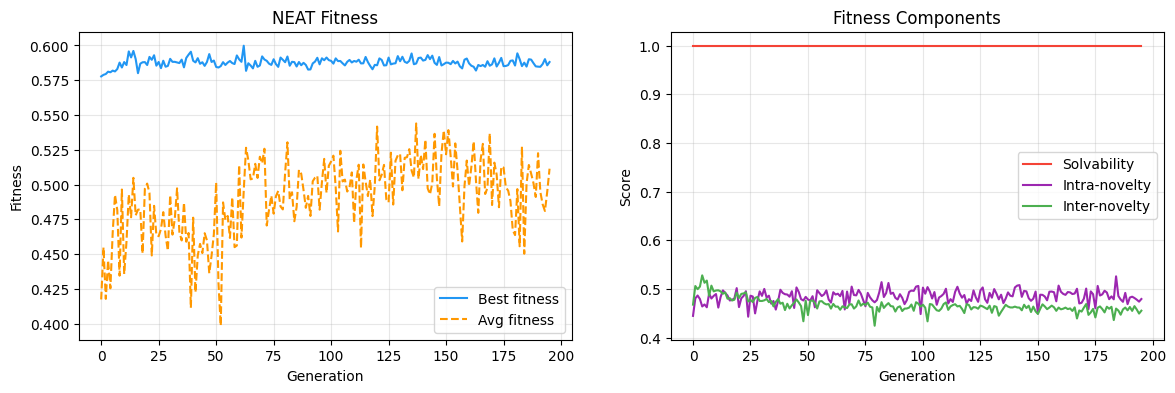


🧬 PCGNN Training (NEAT + Novelty Search — paper-compliant)

Gen   0/200 |░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░| Best: 0.578 Avg:0.417 Solve:1.00 Intra:0.445 Inter:0.468 Archive:1 ETA:0.0m
Gen  20/200 |█████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░| Best: 0.586 Avg:0.501 Solve:1.00 Intra:0.463 Inter:0.481 Archive:21 ETA:8.6m
Gen  40/200 |██████████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░| Best: 0.589 Avg:0.476 Solve:1.00 Intra:0.489 Inter:0.457 Archive:41 ETA:7.8m
Gen  60/200 |███████████████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░| Best: 0.590 Avg:0.514 Solve:1.00 Intra:0.472 Inter:0.459 Archive:61 ETA:6.9m
Gen  80/200 |████████████████████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░| Best: 0.588 Avg:0.508 Solve:1.00 Intra:0.477 Inter:0.463 Archive:81 ETA:6.0m
Gen 100/200 |█████████████████████████░░░░░░░░░░░░░░░░░░░░░░░░░| Best: 0.589 Avg:0.517 Solve:1.00 Intra:0.503 Inter:0.467 Archive:101 ETA:5.0m
Gen 120/200 |██████████████████████████████░░░░░░░░░░░░░░░░░░░░| Best: 0.586 Avg:0.542 

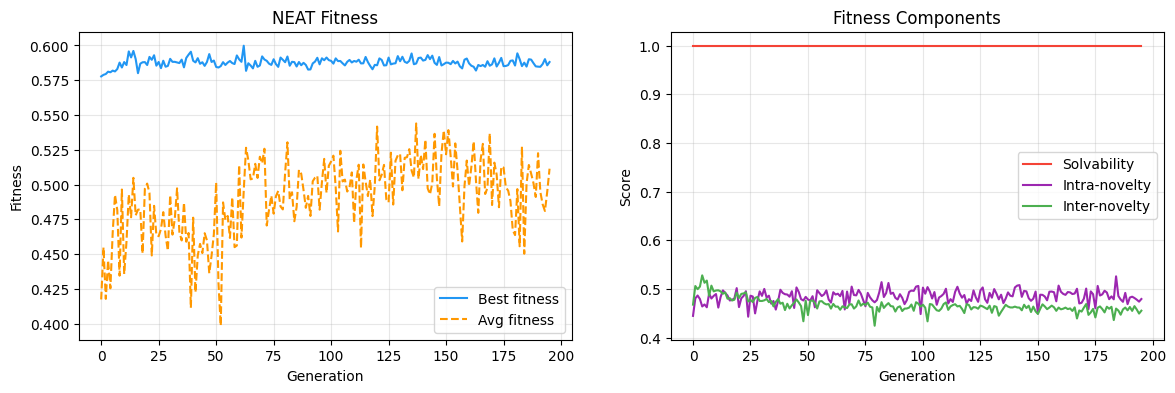

In [26]:
class PCGNNReporter(neat.reporting.BaseReporter):
    def __init__(self, log_interval=10, live_plot_interval=5):
        self.log_interval       = log_interval
        self.live_plot_interval = live_plot_interval
        self.generations  = []
        self.best_fitness = []
        self.avg_fitness  = []
        self.intra_scores = []
        self.inter_scores = []
        self.solve_scores = []
        self.start_time   = None

        self.fig, (self.ax1, self.ax2) = plt.subplots(1, 2, figsize=(14, 4))
        self.bl, = self.ax1.plot([], [], label="Best fitness", color="#2196F3")
        self.al, = self.ax1.plot([], [], label="Avg fitness",  color="#FF9800", linestyle="--")
        self.ax1.set(xlabel="Generation", ylabel="Fitness", title="NEAT Fitness")
        self.ax1.legend(); self.ax1.grid(True, alpha=0.3)
        self.ax2.set(xlabel="Generation", ylabel="Score", title="Fitness Components")
        self.ax2.grid(True, alpha=0.3)

        self.display_id = "pcgnn-live"
        display(self.fig, display_id=self.display_id)

    def start_generation(self, generation):
        if generation == 0:
            self.start_time = time.time()
            print("\n🧬 PCGNN Training (NEAT + Novelty Search — paper-compliant)\n")

    def post_evaluate(self, config, population, species, best_genome):
        global novelty_archive
        gen = len(self.generations)
        self.generations.append(gen)

        fits = [g.fitness for g in population.values() if g.fitness is not None]
        best = max(fits); avg = np.mean(fits)
        self.best_fitness.append(best); self.avg_fitness.append(avg)

        # Sample best genome để log novelty components
        best_net = neat.nn.FeedForwardNetwork.create(best_genome, config)
        sample_levels = [generate_level(best_net) for _ in range(MAPS_PER_GENOME)]
        intra = intra_novelty_score(sample_levels, k=10)
        inter = inter_novelty_score(sample_levels, novelty_archive) if novelty_archive else 0.0
        solve = solvability_fitness(sample_levels)
        self.intra_scores.append(intra); self.inter_scores.append(inter)
        self.solve_scores.append(solve)

        elapsed = time.time() - self.start_time
        eta = (elapsed / (gen+1)) * (MAX_GEN - gen - 1) if gen > 0 else 0
        bar = '█' * int(50*(gen+1)/MAX_GEN) + '░' * (50 - int(50*(gen+1)/MAX_GEN))
        print(f"\rGen {gen:3d}/{MAX_GEN} |{bar}| Best:{best:6.3f} Avg:{avg:5.3f} "
              f"Solve:{solve:.2f} Intra:{intra:.3f} Inter:{inter:.3f} "
              f"Archive:{len(novelty_archive)} ETA:{eta/60:.1f}m",
              end='', flush=True)
        if gen % self.log_interval == 0:
            print()

        if gen % self.live_plot_interval == 0:
            self.bl.set_data(self.generations, self.best_fitness)
            self.al.set_data(self.generations, self.avg_fitness)
            self.ax1.relim(); self.ax1.autoscale_view()

            self.ax2.cla()
            self.ax2.plot(self.generations, self.solve_scores,  label="Solvability", color="#F44336")
            self.ax2.plot(self.generations, self.intra_scores,  label="Intra-novelty", color="#9C27B0")
            self.ax2.plot(self.generations, self.inter_scores,  label="Inter-novelty", color="#4CAF50")
            self.ax2.set(xlabel="Generation", ylabel="Score", title="Fitness Components")
            self.ax2.legend(); self.ax2.grid(True, alpha=0.3)
            update_display(self.fig, display_id=self.display_id)


# ─────────────────────────────────────────────────────────
# TRAINING
# ─────────────────────────────────────────────────────────
novelty_archive = []   # reset archive

config = neat.Config(
    neat.DefaultGenome,
    neat.DefaultReproduction,
    neat.DefaultSpeciesSet,
    neat.DefaultStagnation,
    CONFIG_PATH
)

pop      = neat.Population(config)
reporter = PCGNNReporter(log_interval=20, live_plot_interval=5)
pop.add_reporter(reporter)
pop.add_reporter(neat.StatisticsReporter())

winner = pop.run(eval_genomes, MAX_GEN)

with open(MODEL_PATH, "wb") as f:
    pickle.dump(winner, f)
print(f"\n\n✅ Training done! Winner saved → {MODEL_PATH}")

## Cell 8 - Convergence & Novelty Plot

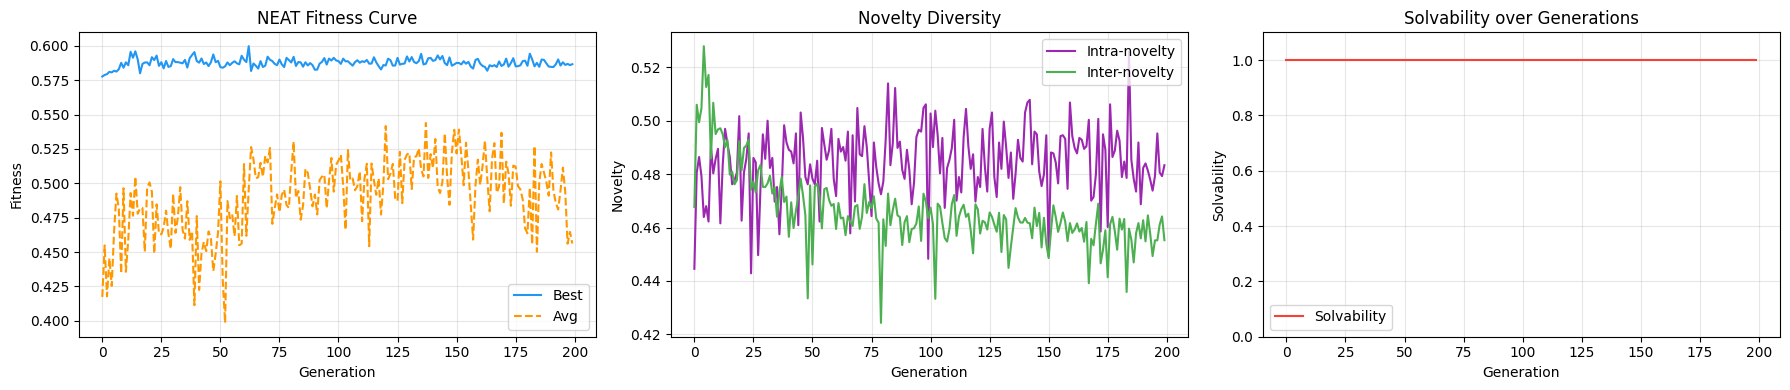

✅ Saved training_curves.png


In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(reporter.generations, reporter.best_fitness, label="Best", color="#2196F3")
axes[0].plot(reporter.generations, reporter.avg_fitness,  label="Avg",  color="#FF9800", linestyle="--")
axes[0].set(xlabel="Generation", ylabel="Fitness", title="NEAT Fitness Curve")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(reporter.generations, reporter.intra_scores, label="Intra-novelty", color="#9C27B0")
axes[1].plot(reporter.generations, reporter.inter_scores, label="Inter-novelty", color="#4CAF50")
axes[1].set(xlabel="Generation", ylabel="Novelty", title="Novelty Diversity")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(reporter.generations, reporter.solve_scores, label="Solvability", color="#F44336")
axes[2].set(xlabel="Generation", ylabel="Solvability", title="Solvability over Generations")
axes[2].set_ylim([0, 1.1]); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Saved training_curves.png")

## Cell 9 - Load Model & Generate Maps

✅ Model loaded


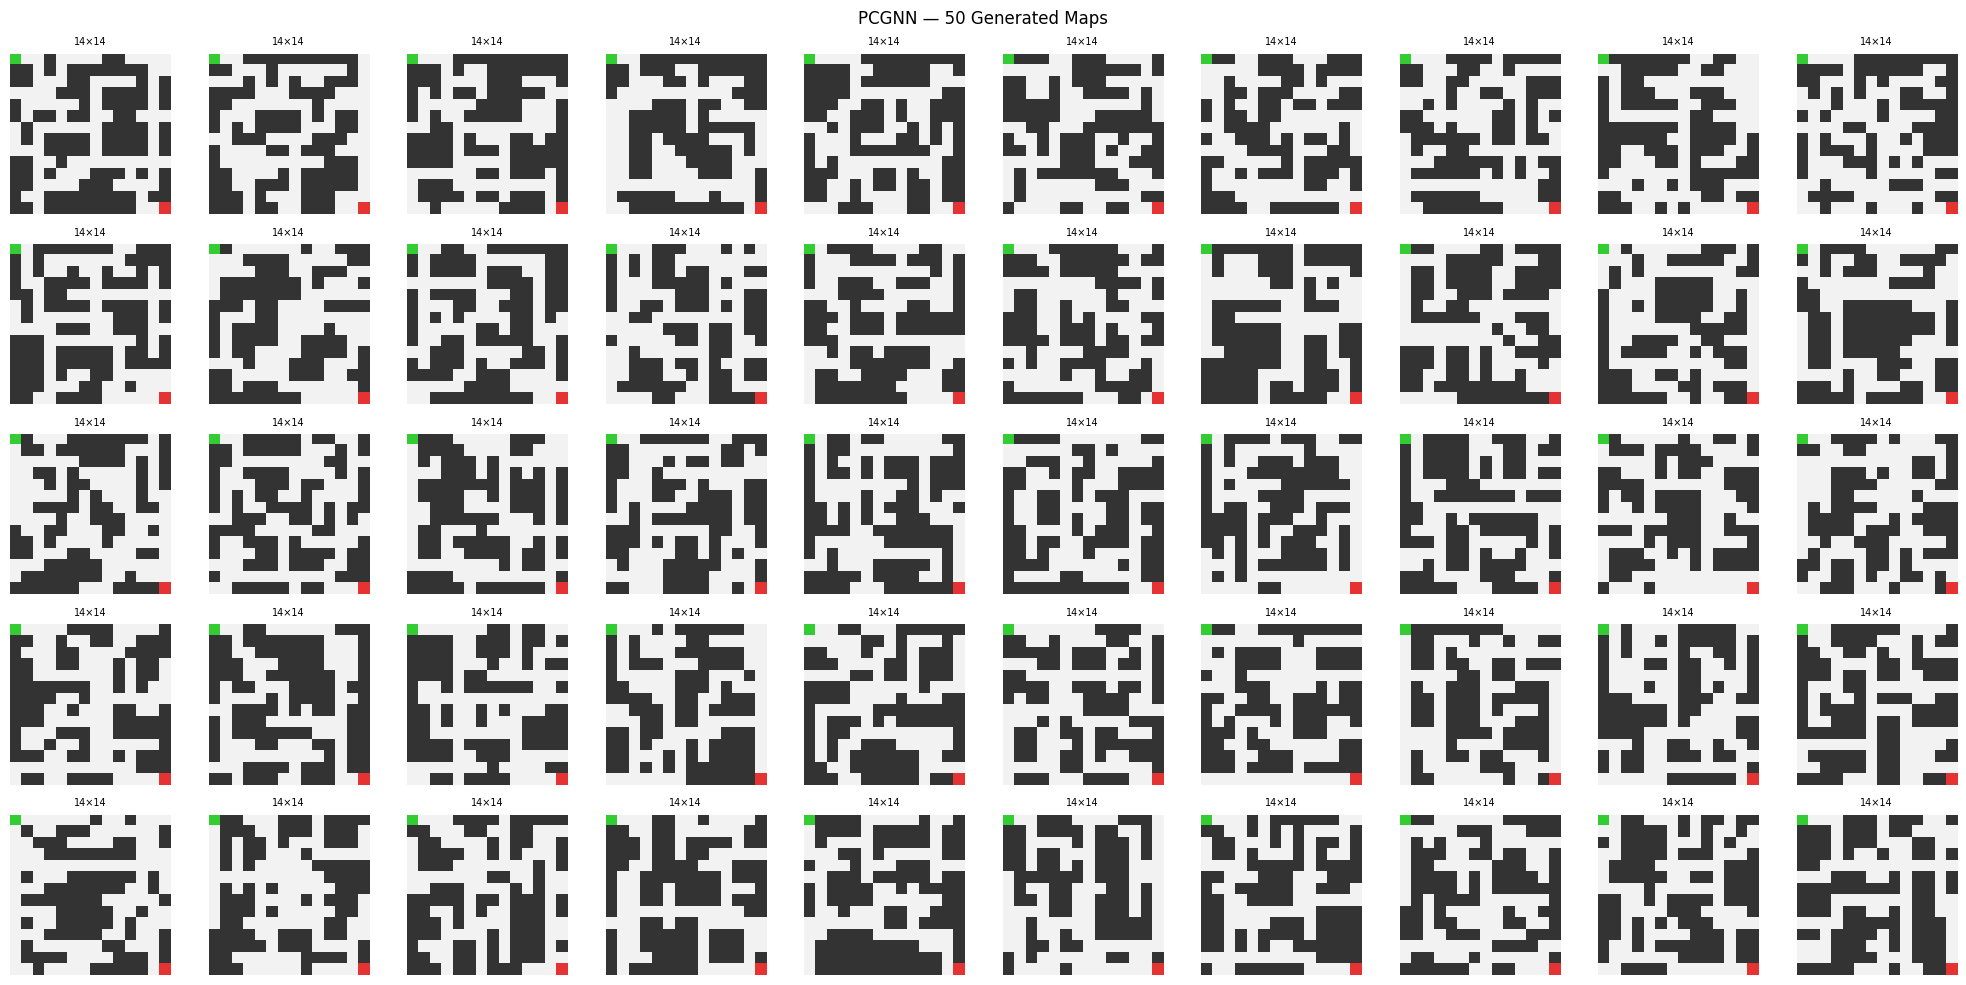

✅ 50 maps saved to saved_maps_txt/


In [28]:
with open(MODEL_PATH, "rb") as f:
    winner_genome = pickle.load(f)

loaded_net = neat.nn.FeedForwardNetwork.create(winner_genome, config)
print("✅ Model loaded")

n_maps = 50
fig, axs = plt.subplots(math.ceil(n_maps/10), 10, figsize=(20, 10))
axs = axs.flatten()

loaded_maps = []
for i in range(n_maps):
    lvl = generate_level(loaded_net)
    loaded_maps.append(lvl.copy())
    lh, lw = lvl.shape
    img = np.zeros((lh, lw, 3))
    for tile, color in TILE_COLORS.items():
        img[lvl == tile] = color
    axs[i].imshow(img, interpolation="nearest")
    axs[i].set_title(f"{lh}×{lw}", fontsize=7)
    axs[i].axis("off")

for j in range(i+1, len(axs)):
    axs[j].axis("off")

plt.suptitle(f"PCGNN — {n_maps} Generated Maps", fontsize=12)
plt.tight_layout()
plt.show()

save_maps_to_txt(loaded_maps, prefix="pcgnn")
print(f"✅ {n_maps} maps saved to {MAP_TXT_DIR}/")

## Cell 10 - Evaluate Final Maps (Paper Metrics: Solvability, Compression Distance, A* Diversity, Leniency)

Computing paper metrics on generated maps...
(A* diversity, edit diversity, leniency may take a moment)

Computing pairwise diversity metrics...
════════════════════════════════════════════════════════
  PCGNN Final Evaluation Report (Paper Metrics)
════════════════════════════════════════════════════════
  Maps generated             : 50

  ── Quality ──────────────────────────────────
  Solvability rate           : 100.0%
  Avg path length            : 27.0
  Avg wall density           : 0.485

  ── Difficulty (paper Table 4) ───────────────
  Avg Leniency               : 0.5227  (↑ = easier, paper≈0.70)
  Avg A* Difficulty          : 0.3837  (↑ = harder, paper≈0.06)

  ── Diversity (paper Table 3) ────────────────
  Avg Compression Dist       : 0.4822  (paper≈0.49)
  Avg A* Diversity           : 0.1224  (paper≈0.04)
  Avg A* Edit Diversity      : 0.4216  (paper≈0.13)
  Avg Visual Diversity       : 0.4878
════════════════════════════════════════════════════════


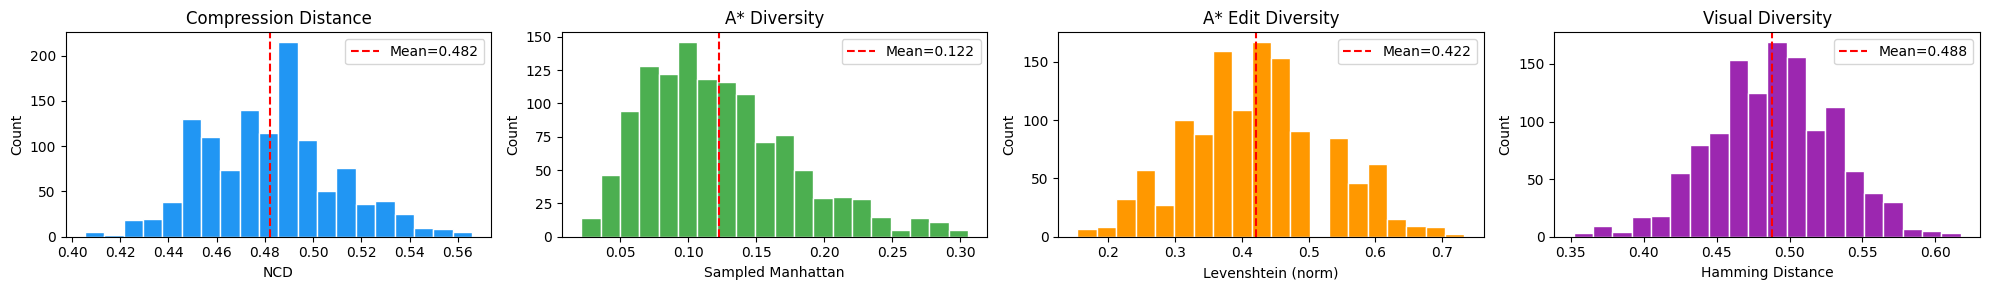

In [29]:
print("Computing paper metrics on generated maps...")
print("(A* diversity, edit diversity, leniency may take a moment)\n")

results = []
for lvl in loaded_maps:
    sp = shortest_path_bfs(lvl)
    results.append({
        "solvable"    : is_solvable(lvl),
        "path_len"    : sp if sp else 0,
        "enemies"     : int(np.sum(lvl == ENEMY)),
        "wall_dens"   : interior_wall_density(lvl),
        "leniency"    : leniency(lvl),
        "astar_diff"  : astar_difficulty(lvl),
    })

# ── Pairwise diversity metrics ────────────────────────────
print("Computing pairwise diversity metrics...")
n = len(loaded_maps)
comp_dists  = []
astar_divs  = []
astar_edit_divs = []
vis_divs    = []

for i in range(n):
    for j in range(i+1, n):
        comp_dists.append(compression_distance(loaded_maps[i], loaded_maps[j]))
        astar_divs.append(astar_diversity(loaded_maps[i], loaded_maps[j]))
        astar_edit_divs.append(astar_edit_diversity(loaded_maps[i], loaded_maps[j]))
        vis_divs.append(visual_diversity(loaded_maps[i], loaded_maps[j]))

# ── Summary ───────────────────────────────────────────────
solve_rate        = np.mean([r["solvable"]   for r in results])
avg_path          = np.mean([r["path_len"]   for r in results])
avg_walldens      = np.mean([r["wall_dens"]  for r in results])
avg_leniency      = np.mean([r["leniency"]   for r in results])
avg_astar_diff    = np.mean([r["astar_diff"] for r in results])
avg_comp_dist     = np.mean(comp_dists)
avg_astar_div     = np.mean(astar_divs)
avg_astar_edit    = np.mean(astar_edit_divs)
avg_vis_div       = np.mean(vis_divs)

print("═" * 56)
print("  PCGNN Final Evaluation Report (Paper Metrics)")
print("═" * 56)
print(f"  Maps generated             : {n}")
print(f"")
print(f"  ── Quality ──────────────────────────────────")
print(f"  Solvability rate           : {solve_rate*100:.1f}%")
print(f"  Avg path length            : {avg_path:.1f}")
print(f"  Avg wall density           : {avg_walldens:.3f}")
print(f"")
print(f"  ── Difficulty (paper Table 4) ───────────────")
print(f"  Avg Leniency               : {avg_leniency:.4f}  (↑ = easier, paper≈0.70)")
print(f"  Avg A* Difficulty          : {avg_astar_diff:.4f}  (↑ = harder, paper≈0.06)")
print(f"")
print(f"  ── Diversity (paper Table 3) ────────────────")
print(f"  Avg Compression Dist       : {avg_comp_dist:.4f}  (paper≈0.49)")
print(f"  Avg A* Diversity           : {avg_astar_div:.4f}  (paper≈0.04)")
print(f"  Avg A* Edit Diversity      : {avg_astar_edit:.4f}  (paper≈0.13)")
print(f"  Avg Visual Diversity       : {avg_vis_div:.4f}")
print("═" * 56)

# ── Plots ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 3))

axes[0].hist(comp_dists, bins=20, color="#2196F3", edgecolor="white")
axes[0].axvline(avg_comp_dist, color="red", linestyle="--", label=f"Mean={avg_comp_dist:.3f}")
axes[0].set(title="Compression Distance", xlabel="NCD", ylabel="Count")
axes[0].legend()

axes[1].hist(astar_divs, bins=20, color="#4CAF50", edgecolor="white")
axes[1].axvline(avg_astar_div, color="red", linestyle="--", label=f"Mean={avg_astar_div:.3f}")
axes[1].set(title="A* Diversity", xlabel="Sampled Manhattan", ylabel="Count")
axes[1].legend()

axes[2].hist(astar_edit_divs, bins=20, color="#FF9800", edgecolor="white")
axes[2].axvline(avg_astar_edit, color="red", linestyle="--", label=f"Mean={avg_astar_edit:.3f}")
axes[2].set(title="A* Edit Diversity", xlabel="Levenshtein (norm)", ylabel="Count")
axes[2].legend()

axes[3].hist(vis_divs, bins=20, color="#9C27B0", edgecolor="white")
axes[3].axvline(avg_vis_div, color="red", linestyle="--", label=f"Mean={avg_vis_div:.3f}")
axes[3].set(title="Visual Diversity", xlabel="Hamming Distance", ylabel="Count")
axes[3].legend()

plt.tight_layout()
plt.savefig("diversity_metrics.png", dpi=120, bbox_inches="tight")
plt.show()

## Cell 11 - Generalisability Test (paper Section 5.5)

Testing generalisability across different map sizes...
(Trained on 8x8–16x16, testing on larger sizes)

  Size    8×8    | Gen time: 3.5ms | Solvability: 100%
  Size   14×14   | Gen time: 6.0ms | Solvability: 100%
  Size   20×20   | Gen time: 11.9ms | Solvability: 100%
  Size   30×30   | Gen time: 32.7ms | Solvability: 100%
  Size   50×50   | Gen time: 85.6ms | Solvability: 100%
  Size  100×100  | Gen time: 345.5ms | Solvability: 100%


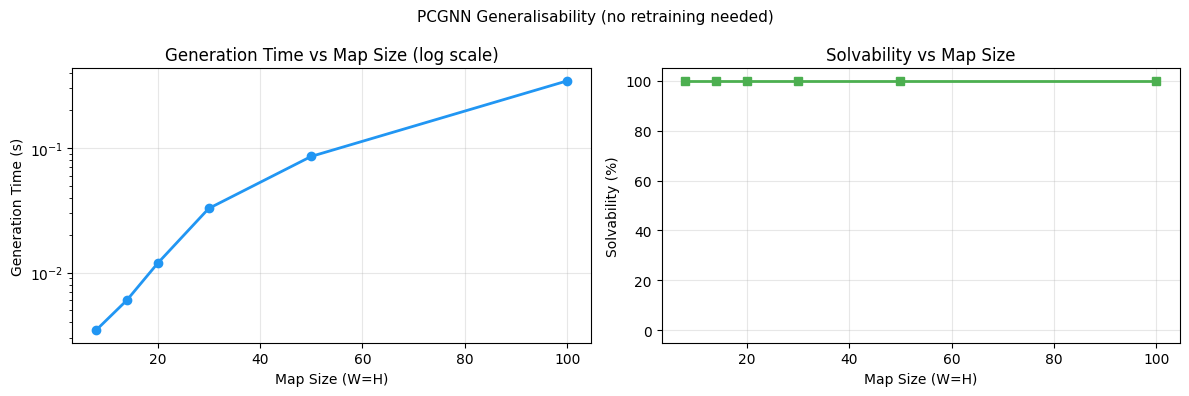


✅ Generalisability test complete


In [30]:
# Paper Section 5.5: test generate level ở size khác với size training
# PCGNN generalizes vì dùng sliding context window, không fixed-size input

print("Testing generalisability across different map sizes...")
print("(Trained on 8x8–16x16, testing on larger sizes)\n")

test_sizes = [8, 14, 20, 30, 50, 100]
gen_times  = []
solv_rates = []
N_TEST     = 10

for sz in test_sizes:
    t0 = time.time()
    maps_sz = []
    for _ in range(N_TEST):
        lvl = generate_level(loaded_net, map_h=sz, map_w=sz)
        maps_sz.append(lvl)
    elapsed = (time.time() - t0) / N_TEST
    solve_r = np.mean([float(is_solvable(m)) for m in maps_sz])
    gen_times.append(elapsed)
    solv_rates.append(solve_r)
    print(f"  Size {sz:4d}×{sz:<4d} | Gen time: {elapsed*1000:.1f}ms | Solvability: {solve_r*100:.0f}%")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.semilogy(test_sizes, gen_times, "o-", color="#2196F3", linewidth=2)
ax1.set(xlabel="Map Size (W=H)", ylabel="Generation Time (s)",
        title="Generation Time vs Map Size (log scale)")
ax1.grid(True, alpha=0.3)

ax2.plot(test_sizes, [s*100 for s in solv_rates], "s-", color="#4CAF50", linewidth=2)
ax2.set(xlabel="Map Size (W=H)", ylabel="Solvability (%)",
        title="Solvability vs Map Size")
ax2.set_ylim([-5, 105]); ax2.grid(True, alpha=0.3)

plt.suptitle("PCGNN Generalisability (no retraining needed)", fontsize=11)
plt.tight_layout()
plt.savefig("generalisability.png", dpi=120, bbox_inches="tight")
plt.show()
print("\n✅ Generalisability test complete")

## Cell 12 - Export ZIP

In [31]:
import shutil
shutil.make_archive('/kaggle/working/saved_maps', 'zip', '/kaggle/working/saved_maps_txt')
print("✅ saved_maps.zip ready for download")

✅ saved_maps.zip ready for download
